# Import libraries

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np

import tensorflow as tf
from keras.layers import Activation, BatchNormalization, Conv2D, Conv1D
from keras import initializers

from sklearn import model_selection

%matplotlib inline
%config InlineBackend.figure_format = 'svg'

2024-06-02 01:08:17.291641: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-06-02 01:08:17.291708: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-06-02 01:08:17.293161: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-06-02 01:08:17.300855: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-06-02 01:08:18.482860: W tensorflow/compiler/tf2

In [2]:
epocas=100

In [3]:
def visualizacion_resultados(history):
    epochs = [i for i in range(epocas)]

    train_acc = history.history['r2_nicolas']
    train_loss = history.history['loss']
    train_lr = history.history['lr']
    val_acc = history.history['val_r2_nicolas']
    val_loss = history.history['val_loss']
    

    fig, ax = plt.subplots(1,3)
    fig.set_size_inches(16,7)

    ax[0].plot(epochs, train_acc, 'go-', label='accuracy-train')
    ax[0].plot(epochs, val_acc, 'ro-', label='accuracy-val')
    ax[0].set_title('Accuracy train')
    ax[0].legend()
    ax[0].set_xlabel('epochs')
    ax[0].set_ylabel('accuracy')
    ax[0].set_ylim(-1,1)

    ax[1].plot(epochs, train_loss, 'go-', label='loss-train')
    ax[1].plot(epochs, val_loss, 'ro-', label='loss-val')
    ax[1].set_title('Loss train')
    ax[1].legend()
    ax[1].set_xlabel('epochs')
    ax[1].set_ylabel('loss')
    
    ax[2].plot(epochs, train_lr, 'go-', label='lr-train')
    ax[2].set_title('Learning Rate train')
    ax[2].legend()
    ax[2].set_xlabel('epochs')
    ax[2].set_ylabel('Learning Rate')
    
    fig.savefig('./plots/training.png')

    plt.show()

# Load data

In [4]:
seis= np.load('../data_decatur/processed/seismic-ccs1-vw1-inline.npy')
phi_true = np.load('../data_decatur/processed/porosity-ccs1-vw1-inline.npy')

# Shape and Statistics

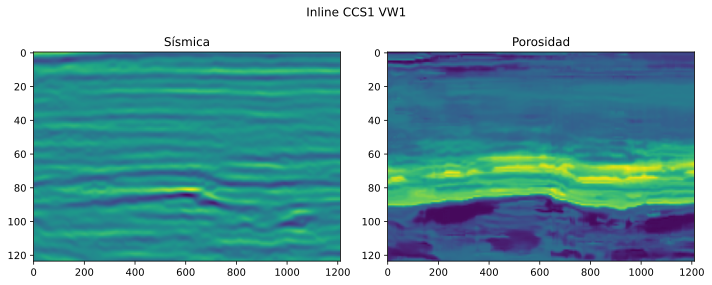

In [5]:
fig, ax = plt.subplots(1,2, figsize = (10, 4))
fig.suptitle('Inline CCS1 VW1')
ax[0].imshow(seis.T)
ax[0].set_title('Sísmica')
ax[0].set_aspect('auto')
ax[1].imshow(phi_true.T)
ax[1].set_title('Porosidad')
ax[1].set_aspect('auto')
fig.tight_layout()
fig.savefig("./plots/section_original.png")
plt.show()

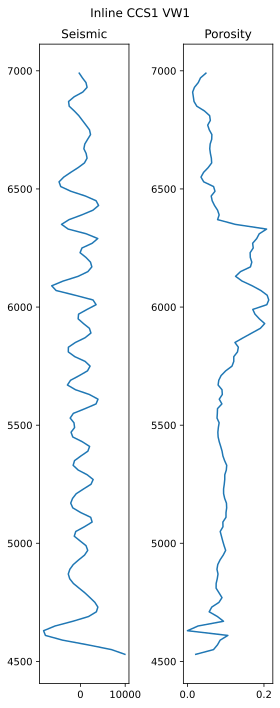

In [6]:
depth = np.arange(4530, 7010, 20)
fig, ax = plt.subplots(1,2, figsize = (4, 10))
fig.suptitle('Inline CCS1 VW1')
ax[0].plot(seis[15,:], depth)
ax[0].set_title('Seismic')
ax[0].set_aspect('auto')
ax[1].plot(phi_true[15,:], depth)
ax[1].set_title('Porosity')
ax[1].set_aspect('auto')
fig.tight_layout()
fig.savefig("./plots/traza_original.svg")
plt.show()

In [7]:
seis.shape

(1211, 124)

In [8]:
phi_true.shape

(1211, 124)

In [9]:
phi_true.mean()

0.09534691464450182

In [10]:
phi_true.min()

1.0961666703224182e-05

In [11]:
phi_true.max()

0.24446946382522583

(array([ 1.,  5.,  6.,  2.,  2.,  9., 11., 25., 17., 14.,  2.,  2.,  3.,
         3.,  1.,  6.,  5.,  4.,  2.,  4.]),
 array([1.00000000e-04, 1.06211326e-02, 2.11422652e-02, 3.16633978e-02,
        4.21845303e-02, 5.27056629e-02, 6.32267955e-02, 7.37479281e-02,
        8.42690607e-02, 9.47901933e-02, 1.05311326e-01, 1.15832458e-01,
        1.26353591e-01, 1.36874724e-01, 1.47395856e-01, 1.57916989e-01,
        1.68438121e-01, 1.78959254e-01, 1.89480387e-01, 2.00001519e-01,
        2.10522652e-01]),
 <BarContainer object of 20 artists>)

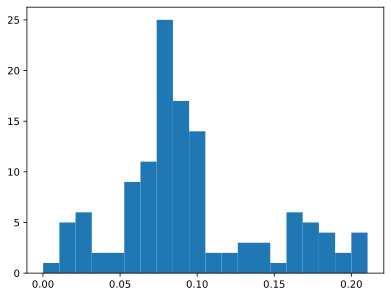

In [12]:
plt.hist(phi_true[0], bins=20)

# Normalizacion de Datos

In [13]:
def min_max_scale(x, min, max):

  x_std = (x - min) / (max - min)
  x_scaled = x_std * 2 - 1
  return x_scaled

def inverse_min_max_scale(x, min, max):

  x_normalized = (x + 1) / 2
  x_unscaled = x_normalized * (max - min) + min
  return x_unscaled

In [14]:
phi_max=np.max(phi_true) #can also take 1 or critical porosity (0.4)
phi_min=np.min(phi_true) #can also take 0

In [15]:
phi_scaled = min_max_scale(phi_true, min= phi_min, max=phi_max)
phi_unscaled = inverse_min_max_scale(phi_scaled, min= phi_min, max=phi_max)

(array([ 1.,  5.,  6.,  2.,  2.,  9., 11., 25., 17., 14.,  2.,  2.,  3.,
         3.,  1.,  6.,  5.,  4.,  2.,  4.]),
 array([-0.99927155, -0.9131945 , -0.82711746, -0.74104042, -0.65496337,
        -0.56888633, -0.48280928, -0.39673224, -0.3106552 , -0.22457815,
        -0.13850111, -0.05242407,  0.03365298,  0.11973002,  0.20580707,
         0.29188411,  0.37796115,  0.4640382 ,  0.55011524,  0.63619228,
         0.72226933]),
 <BarContainer object of 20 artists>)

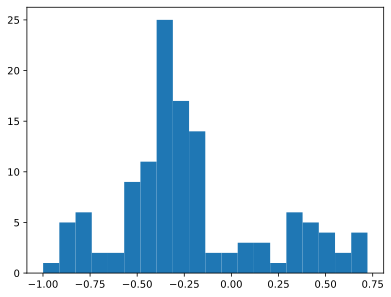

In [16]:
plt.hist(phi_scaled[0], bins=20)

(array([ 1.,  5.,  6.,  2.,  2.,  9., 11., 25., 17., 14.,  2.,  2.,  3.,
         3.,  1.,  6.,  5.,  4.,  2.,  4.]),
 array([1.00000000e-04, 1.06211326e-02, 2.11422652e-02, 3.16633978e-02,
        4.21845303e-02, 5.27056629e-02, 6.32267955e-02, 7.37479281e-02,
        8.42690607e-02, 9.47901933e-02, 1.05311326e-01, 1.15832458e-01,
        1.26353591e-01, 1.36874724e-01, 1.47395856e-01, 1.57916989e-01,
        1.68438121e-01, 1.78959254e-01, 1.89480387e-01, 2.00001519e-01,
        2.10522652e-01]),
 <BarContainer object of 20 artists>)

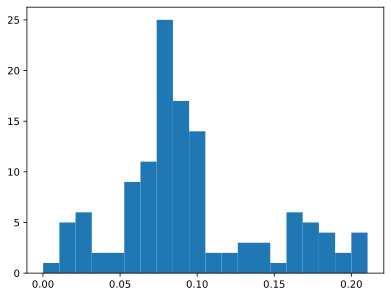

In [17]:
plt.hist(phi_unscaled[0], bins=20)

In [18]:
# Normalizing the input and output data  

seis_normalized = (seis - np.min(seis))/(np.max(seis)-np.min(seis))


true_output=np.zeros((seis_normalized.shape[0],seis_normalized.shape[1]))
true_output[:,0:199]=(phi_true-phi_min)/(phi_max-phi_min)

In [19]:
true_output.shape

(1211, 124)

In [20]:
np.min(seis), np.max(seis)

(-16131.97265625, 17048.5546875)

In [21]:
np.min(true_output), np.max(true_output)

(0.0, 1.0)

In [22]:
seis.shape, phi_scaled.shape

((1211, 124), (1211, 124))

# Preparación de Datos

In [23]:
train_wells = 100

val_well = 2

X_train = []
Y_train = []

for i in range(0,train_wells):
    random_well = np.random.randint(0,seis_normalized.shape[0])
    
    X_chosen = seis_normalized[random_well, :]
    Y_chosen = phi_scaled[random_well, :]
    X_chosen = np.expand_dims(X_chosen, axis=0)
    Y_chosen = np.expand_dims(Y_chosen, axis=0)

    X_train.append(X_chosen)
    Y_train.append(Y_chosen)

    seis_normalized = np.delete(seis_normalized, random_well, 0)
    phi_scaled = np.delete(phi_scaled, random_well, 0)
    
X_train = np.concatenate(X_train, axis=0)
Y_train = np.concatenate(Y_train, axis=0)

#Un pozo de validacion
random_well = np.random.randint(0,seis_normalized.shape[0])
X_val = seis_normalized[random_well, :]
Y_val = phi_scaled[random_well, :]

seis_normalized = np.delete(seis_normalized, random_well, 0)
phi_scaled = np.delete(phi_scaled, random_well, 0)

X_test = seis_normalized
Y_test = phi_scaled

#X_val,X_test,Y_val,Y_test = model_selection.train_test_split(seis,phi_scaled, test_size=0.50, random_state=13)

#X_train,X_test,Y_train,Y_test = model_selection.train_test_split(seis,phi_scaled, test_size=0.20, random_state=1)

#X_test,X_val,Y_test,Y_val = model_selection.train_test_split(seis,phi_scaled, test_size=0.5, random_state=1)


## Revision y ajustes finales

In [24]:
"""Esta noramlización de los datos se hace para que los datos puedan entrar al modelo Conv1D. 
TensotFlow recibe un tensor de 3 Dimensiones de la forma (samples, timesteps, features).
Por lo cual es necesario agregar una tercera dimensión"""
X_train_final = np.expand_dims(X_train, axis=1)
X_test_final = np.expand_dims(X_test, axis=1)

X_val_final = X_val.reshape([1, -1])
X_val_final = np.expand_dims(X_val_final, axis=1)

Y_val_final = Y_val.reshape([1, -1])
#Y_val_final = np.expand_dims(Y_val_final, axis=1)

In [25]:
print(f'Shape train: {X_train_final.shape}')
print(f'Shape test: {X_test_final.shape}')
print(f'Shape val: {X_val_final.shape}')

Shape train: (100, 1, 124)
Shape test: (1110, 1, 124)
Shape val: (1, 1, 124)


# Arquitectura Red Neuronal

In [26]:
given_seed=2
def get_model():
    """El input shape de tal forma sería entonces (1, 246) ya que son trazas sismicas, 2000 de ellas"""
    model = tf.keras.models.Sequential(
        #probar a poner capa densa al comienzo y luego pasar por la convolución
    [tf.keras.layers.Dense(units=124), #reducir capas flatten
    BatchNormalization(),
    Activation('tanh'),        
        
    Conv1D(filters=512, kernel_size=3,
                            kernel_initializer=initializers.he_uniform(seed=given_seed), bias_initializer='zeros', padding='same'),
    BatchNormalization(),
    Activation('tanh'),
    
    Conv1D(filters=512, kernel_size=3, padding='same', 
                            kernel_initializer=initializers.he_uniform(seed=given_seed), bias_initializer='zeros',),
    BatchNormalization(),
    Activation('tanh'),
    
    Conv1D(filters=512, kernel_size=3, padding='same', 
                            kernel_initializer=initializers.he_uniform(seed=given_seed), bias_initializer='zeros',),
    BatchNormalization(),
    Activation('tanh'),
    
    Conv1D(filters=512, kernel_size=3, padding='same', 
                            kernel_initializer=initializers.he_uniform(seed=given_seed), bias_initializer='zeros',),
    BatchNormalization(),
    Activation('tanh'),
    
    Conv1D(filters=512, kernel_size=3, padding='same', 
                            kernel_initializer=initializers.he_uniform(seed=given_seed), bias_initializer='zeros',),
    BatchNormalization(),
    Activation('tanh'),
    Conv1D(filters=512, kernel_size=3, padding='same', 
                            kernel_initializer=initializers.he_uniform(seed=given_seed), bias_initializer='zeros',),
    BatchNormalization(),
    Activation('tanh'),

    #tratar de cambiar el padding same 
    #batch normalization, da estabilidad. Para ponerlo despues de la ultima conv, luego el batch y luego la activación
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(units=200), #reducir capas flatten
    BatchNormalization(),
    Activation('tanh'),
    
    tf.keras.layers.Dense(units=124), #probar softmax, sigmoid, leakyrelu, linear
    Activation('tanh')
])
    return model

def naive_model():
    """El input shape de tal forma sería entonces (1, 246) ya que son trazas sismicas, 2000 de ellas"""

    model = tf.keras.models.Sequential()
        #probar a poner capa densa al comienzo y luego pasar por la convolución
    input_final = tf.keras.Input(shape=(X_train_final.shape[1:]))
    model.add(input_final)
    #model.add(tf.keras.layers.Reshape((-1,1)))
    
    model.add(Conv1D(filters=128, kernel_size=3, strides=1, padding='same',kernel_initializer=initializers.he_uniform(seed=given_seed), bias_initializer='zeros')) 
    model.add(Activation('tanh'))
    
    model.add(Conv1D(filters=256, kernel_size=3, strides=1, padding='same',kernel_initializer=initializers.he_uniform(seed=given_seed), bias_initializer='zeros')) 
    model.add(Activation('tanh'))
    
    model.add(Conv1D(filters=512, kernel_size=3, strides=1, padding='same',kernel_initializer=initializers.he_uniform(seed=given_seed), bias_initializer='zeros')) 
    model.add(Activation('tanh'))
    
    model.add(Conv1D(filters=1024, kernel_size=3, strides=1, padding='same',kernel_initializer=initializers.he_uniform(seed=given_seed), bias_initializer='zeros')) 
    model.add(Activation('tanh'))
    model.add(tf.keras.layers.Dropout(rate=0.3))
    

    model.add(tf.keras.layers.Flatten())
 
    
    model.add(tf.keras.layers.Dense(units=124,kernel_initializer=initializers.he_uniform(seed=given_seed), bias_initializer='zeros'))
    model.add(Activation('tanh'))

    return model
    

model_phi = naive_model()
model_phi.build((None,124,1))
model_phi.summary()


2024-06-02 01:08:22.677263: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-06-02 01:08:22.712160: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-06-02 01:08:22.712226: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-06-02 01:08:22.715227: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-06-02 01:08:22.715355: I external/local_xla/xla/stream_executor

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 1, 128)            47744     
                                                                 
 activation (Activation)     (None, 1, 128)            0         
                                                                 
 conv1d_1 (Conv1D)           (None, 1, 256)            98560     
                                                                 
 activation_1 (Activation)   (None, 1, 256)            0         
                                                                 
 conv1d_2 (Conv1D)           (None, 1, 512)            393728    
                                                                 
 activation_2 (Activation)   (None, 1, 512)            0         
                                                                 
 conv1d_3 (Conv1D)           (None, 1, 1024)           1

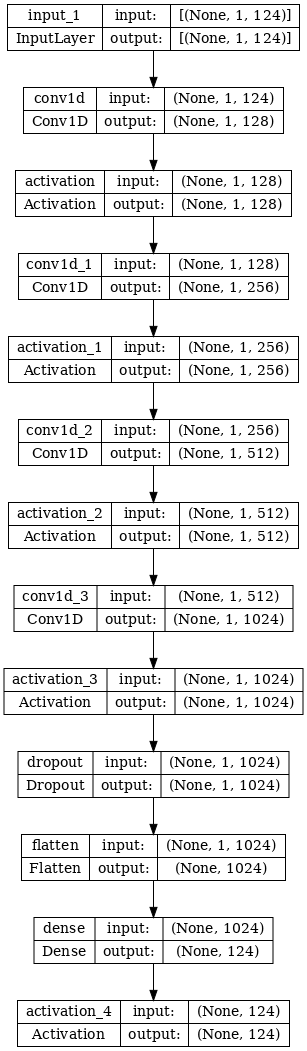

In [27]:
tf.keras.utils.plot_model(model_phi, show_shapes=True, dpi=72, to_file='model.png')

In [28]:
def r2_nicolas(Y_val_final, phi_pred):
    sum_squares_residuals = tf.reduce_sum((Y_val_final - phi_pred) ** 2)
    sum_squares = tf.reduce_sum((Y_val_final - tf.reduce_mean(Y_val_final)) ** 2)
    R2 = 1 - sum_squares_residuals / sum_squares
    return R2

In [29]:
optimizer = tf.keras.optimizers.Adam()

model_phi.compile(optimizer=optimizer,
                    loss='mse',
                    metrics=r2_nicolas)

In [30]:
os.remove("model_naive.h5")

In [31]:
#callback_early = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=5, mode='auto')
checkpoint = tf.keras.callbacks.ModelCheckpoint('model_naive.h5', 
                                                monitor='val_r2_nicolas', 
                                                mode='max', 
                                                verbose=1, 
                                                save_weights_only=True)

callback_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='r2_nicolas', 
                                                   factor=0.5, 
                                                   patience=50, 
                                                   min_lr=0.000001)

# Entrenamiento

In [32]:
history_early = model_phi.fit(x=X_train_final, 
                                y=Y_train,
                                epochs=epocas,
                                batch_size=100,
                                callbacks=[checkpoint, callback_lr],
                                validation_data=(X_val_final, Y_val_final)                          
                                )

Epoch 1/100


2024-06-02 01:08:25.055137: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2024-06-02 01:08:25.287681: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2024-06-02 01:08:25.466913: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2024-06-02 01:08:26.812828: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f08561ca660 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-06-02 01:08:26.812890: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce GTX 1050, Compute Capability 6.1
2024-06-02 01:08:26.821376: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1717308506.977810    5836 device_compiler.

1/1 [==============================] - ETA: 0s - loss: 0.3165 - r2_nicolas: -0.8368
Epoch 1: saving model to model_naive.h5
1/1 [==============================] - 7s 7s/step - loss: 0.3165 - r2_nicolas: -0.8368 - val_loss: 0.0382 - val_r2_nicolas: 0.7518 - lr: 0.0010
Epoch 2/100
1/1 [==============================] - ETA: 0s - loss: 0.0789 - r2_nicolas: 0.5422
Epoch 2: saving model to model_naive.h5
1/1 [==============================] - 0s 111ms/step - loss: 0.0789 - r2_nicolas: 0.5422 - val_loss: 0.0293 - val_r2_nicolas: 0.8101 - lr: 0.0010
Epoch 3/100
1/1 [==============================] - ETA: 0s - loss: 0.0622 - r2_nicolas: 0.6391
Epoch 3: saving model to model_naive.h5
1/1 [==============================] - 0s 127ms/step - loss: 0.0622 - r2_nicolas: 0.6391 - val_loss: 0.0296 - val_r2_nicolas: 0.8078 - lr: 0.0010
Epoch 4/100
1/1 [==============================] - ETA: 0s - loss: 0.0606 - r2_nicolas: 0.6483
Epoch 4: saving model to model_naive.h5
1/1 [==============================

In [33]:
print(history_early.history.keys())

dict_keys(['loss', 'r2_nicolas', 'val_loss', 'val_r2_nicolas', 'lr'])


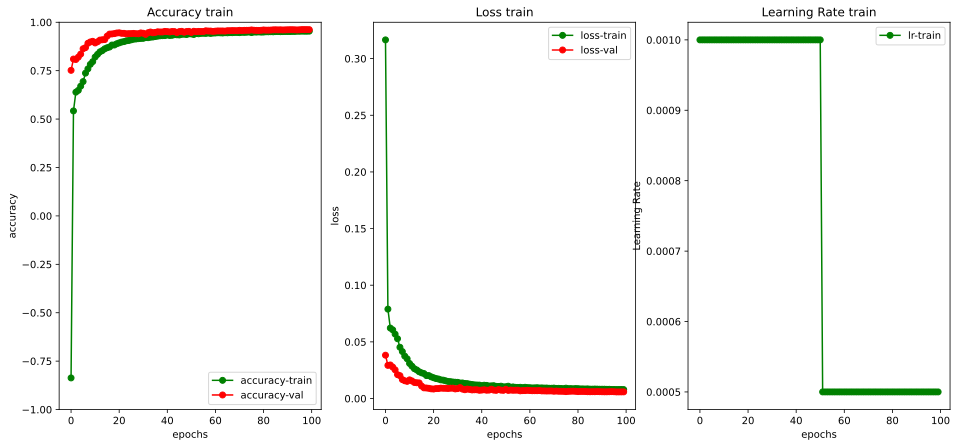

In [34]:
visualizacion_resultados(history_early)

# Test del Modelo

## Mismos Datos

In [35]:
# load the saved model
model_phi.load_weights('model_naive.h5')

In [36]:
loss, accuracy = model_phi.evaluate(X_val_final, Y_val_final)

1/1 [==============================] - 0s 40ms/step - loss: 0.0059 - r2_nicolas: 0.9619


In [37]:
phi_pred = model_phi.predict(X_test_final)

35/35 [==============================] - 1s 13ms/step


In [38]:
phi_pred_true = inverse_min_max_scale(phi_pred, phi_min, phi_max)

In [39]:
depth = np.arange(0,124)

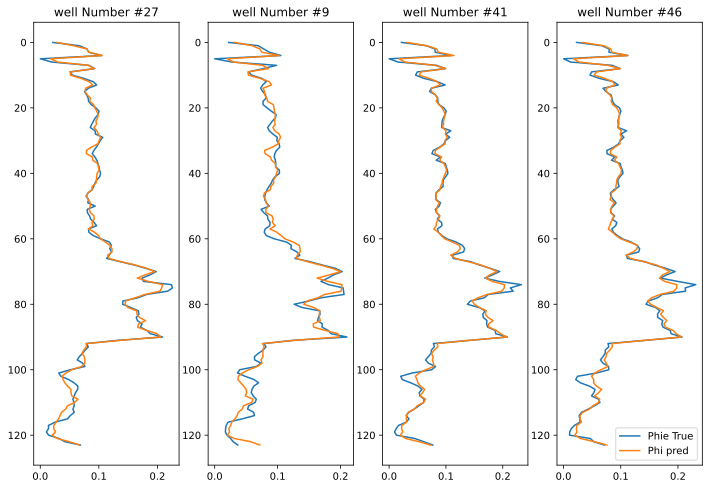

In [40]:
fig, ax = plt.subplots(1,4, figsize=(12, 8))
for i in range(0,4):
    well_number = np.random.randint(0,50)
    one_log_pred = phi_pred_true[well_number,:]
    one_log_true = phi_true[well_number,:]
    ax[i].plot(one_log_true, depth,label='Phie True')
    ax[i].plot(one_log_pred, depth, label='Phi pred')

    ax[i].invert_yaxis()  # This will flip the y-axis
    ax[i].set_title(f'well Number #{well_number}')
plt.legend()

plt.show()


In [41]:
fig.savefig("./plots/predictions.png")

## Seccion

In [42]:
seis_secc =np.expand_dims(seis_normalized, axis=1)
phi_pred__full_line = model_phi.predict(seis_secc)
phi_pred__full_line = inverse_min_max_scale(phi_pred__full_line, phi_min, phi_max)

35/35 [==============================] - 0s 4ms/step


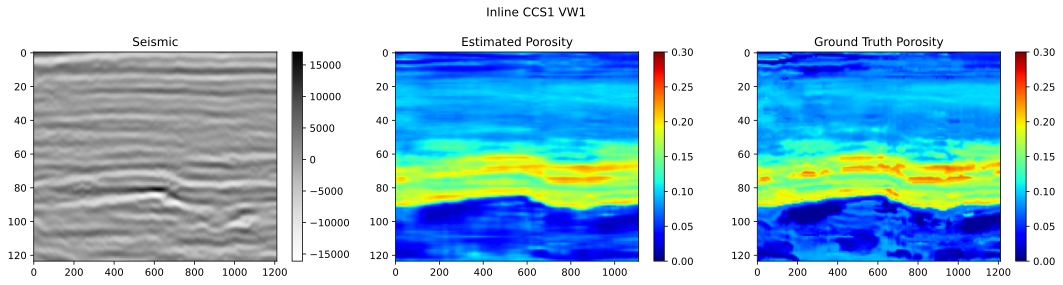

In [43]:
fig, ax = plt.subplots(1,3, figsize = (15, 4))

fig.suptitle('Inline CCS1 VW1')

im1 = ax[0].imshow(seis.squeeze().T, cmap='Greys')
ax[0].set_title('Seismic')
ax[0].set_aspect('auto')
fig.colorbar(im1, ax=ax[0], shrink=1)

im2 = ax[1].imshow(phi_pred__full_line.T, vmin=0, vmax=0.3, cmap='jet')
ax[1].set_title('Estimated Porosity')
ax[1].set_aspect('auto')
fig.colorbar(im2, ax=ax[1], shrink=1)

im3 = ax[2].imshow(phi_true.T, vmin=0, vmax=0.3, cmap='jet')
ax[2].set_title('Ground Truth Porosity')
ax[2].set_aspect('auto')
fig.colorbar(im3, ax=ax[2], shrink=1)
fig.tight_layout()
        
fig.savefig("./plots/section_predicted_inline.png")
fig.savefig("./plots/section_predicted_inline.pdf", format="pdf", bbox_inches="tight")
plt.show()


In [44]:
seis_line = np.load('../data_decatur/processed/seismic-ccs1-xline.npy')
phi_test = np.load('../data_decatur/processed/porosity-ccs1-xline.npy')
seis_test = np.expand_dims(seis_line, axis=1)
seis_test_normalized = (seis_test - np.min(seis_test))/(np.max(seis_test)-np.min(seis_test))
phi_pred_new_line = model_phi.predict(seis_test_normalized)
phi_min = np.min(phi_test)
phi_max = np.max(phi_test)
phi_pred_true_new_line = inverse_min_max_scale(phi_pred_new_line, phi_min, phi_max)

6/6 [==============================] - 0s 64ms/step


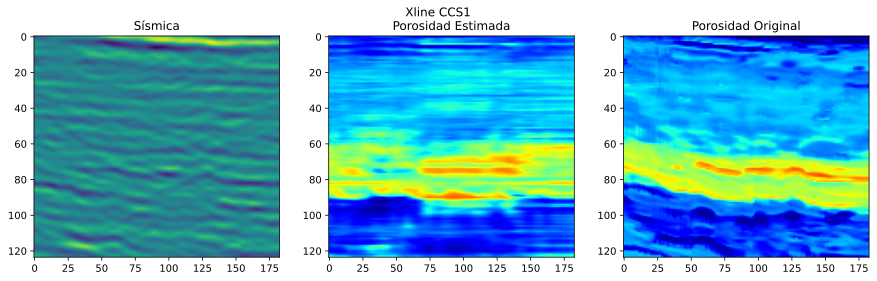

In [45]:
fig, ax = plt.subplots(1,3, figsize = (15, 4))
fig.suptitle('Xline CCS1')
ax[0].imshow(seis_test_normalized.squeeze().T)
ax[0].set_title('Sísmica')
ax[0].set_aspect('auto')
ax[1].imshow(phi_pred_true_new_line.T, vmin=0, vmax=0.3, cmap='jet')
ax[1].set_title('Porosidad Estimada')
ax[1].set_aspect('auto')
ax[2].imshow(phi_test.T, vmin=0, vmax=0.3, cmap='jet')
ax[2].set_title('Porosidad Original')
ax[2].set_aspect('auto')

fig.savefig("./plots/section_predicted.png")
fig.savefig("./plots/section_predicted.pdf", format="pdf", bbox_inches="tight")

In [46]:
seis_test_normalized.shape

(183, 1, 124)

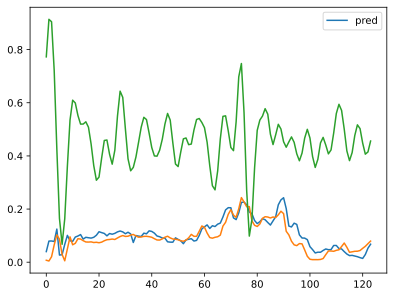

In [47]:
plt.plot(phi_pred_true_new_line[100,:].T, label='pred')
plt.plot(phi_test[100,:].T)
plt.plot(seis_test_normalized[100,:].T)
plt.legend()